In [1]:
import pandas as pd

url = "https://gist.githubusercontent.com/netj/8836201/raw/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [2]:
df.info()
df["variety"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,count
variety,
Setosa,50
Versicolor,50
Virginica,50


In [3]:
X = df.drop("variety", axis=1)
y = df["variety"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,   # makes tree simple and readable
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


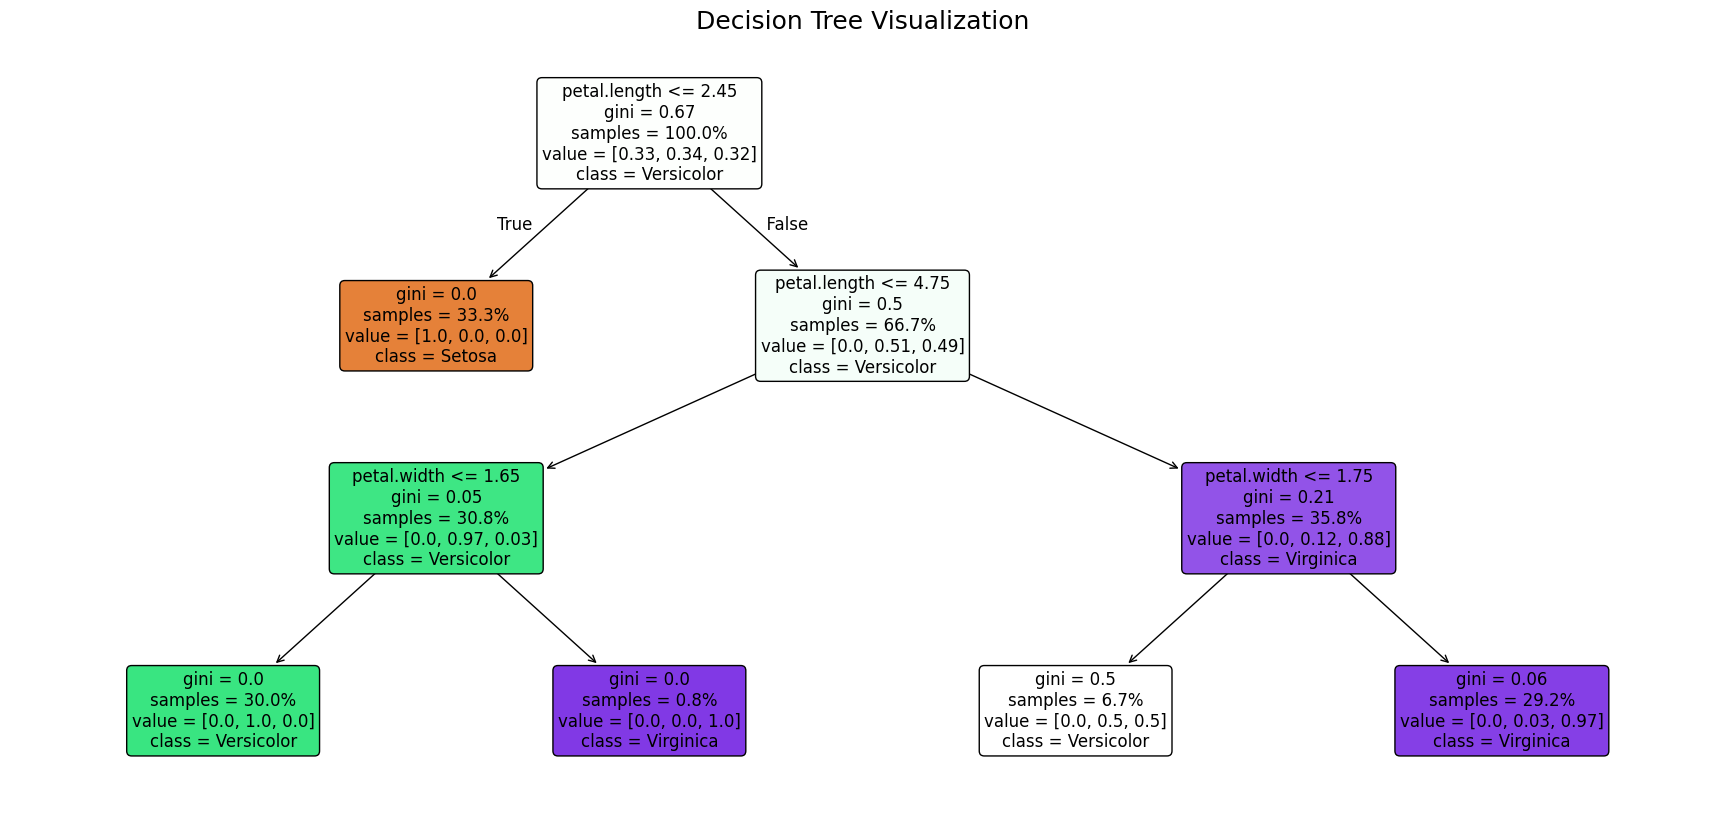

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,              # colorful nodes
    rounded=True,             # rounded boxes
    proportion=True,          # shows percentages
    precision=2,
    fontsize=12
)

plt.title("Decision Tree Visualization", fontsize=18)
plt.show()